<a href="https://colab.research.google.com/github/juank2572/Aula-matematicas/blob/main/ACTIVIDAD3_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LKNNKNKN

# 📊 Estudio Comparativo de Modelos de Aprendizaje Supervisado
## Clasificación de Pobreza Multidimensional — Encuesta Nacional de Hogares 2023

**Asignatura:** Inteligencia Artificial / Machine Learning  
**Actividad:** 05 — Estudio Comparativo de Modelos de Aprendizaje Supervisado  
**Dataset:** Encuesta Nacional de Hogares — Colombia 2023  
**Plataforma:** Google Colab / Vertex AI  

---

## 1. Introducción

El presente informe desarrolla un estudio comparativo de modelos de aprendizaje
supervisado aplicado a un problema de clasificación de pobreza multidimensional
en Colombia. El objetivo principal es evaluar y comparar el desempeño de diferentes
algoritmos de clasificación, identificar sus ventajas y desventajas, y tomar una
decisión fundamentada sobre cuál modelo es más adecuado para este problema.

### 1.1 Contexto del problema

La pobreza multidimensional es un indicador que va más allá del ingreso económico.
Evalúa carencias simultáneas en dimensiones como educación, salud, trabajo y
condiciones de vivienda. El dataset utilizado proviene de la Encuesta Nacional
de Hogares de Colombia (2023) y contiene información de miles de hogares a nivel
nacional, incluyendo variables de vivienda, servicios públicos, empleo, educación
y el indicador de pobreza multidimensional (variable `ipmpobre`).

### 1.2 Objetivo del estudio

> Predecir si un hogar es pobre multidimensionalmente (`ipmpobre = 1`) o no
> (`ipmpobre = 0`), utilizando características de vivienda, servicios, empleo
> y educación, y comparar el rendimiento de al menos tres modelos supervisados
> de clasificación.

---

In [1]:
# =============================================================================
# ACTIVIDAD 05: ESTUDIO COMPARATIVO DE MODELOS SUPERVISADOS
# FASE: CARGA DESDE DRIVE Y LIMPIEZA TÉCNICA
# =============================================================================

import pandas as pd
from google.colab import drive
import os

# 1. MONTAJE DEL DRIVE
# Al ejecutar esto, Colab te pedirá permiso para acceder a tus archivos.
drive.mount('/content/drive')

# 2. DEFINICIÓN DE LA RUTA (Basada en tu estructura de carpetas)
ruta_dataset = '/content/drive/MyDrive/DATA SETS/hogares(Nacional)2023.csv'

# 3. CARGA DEL ARCHIVO
if os.path.exists(ruta_dataset):
    df = pd.read_csv(ruta_dataset)
    print("✅ Archivo cargado exitosamente desde Google Drive.")
else:
    print("❌ Error: No se encontró el archivo en la ruta especificada.")

# 4. ACTIVIDADES DE LIMPIEZA Y DIAGNÓSTICO (Protocolo de Ciencia de Datos)
print("\n" + "="*30)
print("DIAGNÓSTICO INICIAL DEL DATASET")
print("="*30)

# A. Visualización de las primeras 5 filas
print("\n📌 Primeras 5 filas del dataset:")
display(df.head())

# B. Determinación de Filas Duplicadas
duplicados = df.duplicated().sum()
print(f"\n📌 Filas duplicadas encontradas: {duplicados}")

# C. Determinación de Valores Nulos
nulos_totales = df.isnull().sum().sum()
nulos_por_columna = df.isnull().sum()
print(f"📌 Valores nulos totales en el dataset: {nulos_totales}")

if nulos_totales > 0:
    print("\nDetalle de nulos por columna:")
    print(nulos_por_columna[nulos_por_columna > 0])
else:
    print("✔️ No hay fallas de integridad por valores nulos.")

# D. Consistencia de Tipos de Datos
print("\n📌 Resumen de tipos de datos:")
print(df.dtypes.value_counts())

# E. Verificación de la Variable Objetivo (Clasificación Supervisada)
if 'pobre' in df.columns:
    distribucion = df['pobre'].value_counts(normalize=True) * 100
    print("\n📌 Distribución de la variable objetivo 'pobre' (Desbalance de clases):")
    print(f"No Pobres (0): {distribucion[0]:.2f}%")
    print(f"Pobres (1):    {distribucion[1]:.2f}%")

Mounted at /content/drive
✅ Archivo cargado exitosamente desde Google Drive.

DIAGNÓSTICO INICIAL DEL DATASET

📌 Primeras 5 filas del dataset:


,PERIODO,DIRECTORIO,SECUENCIA_P,SECUENCIA_ENCUESTA,P5010,P8526,P8530,P1075,P1077S21,P1077S22,...,trabajo_infantil,atencion_integral,inasistencia_escolar,rezago_escolar,alfabetismo,logro_educativo,hacinamiento,ipm,pobre,fexp
0,20230939,7910114,1,1,2,1,1,2,1,2,...,0,0,0,0,0,0,0,0.1,0,564.741890
1,20230939,7910119,1,1,2,2,1,1,2,2,...,0,0,0,0,0,1,0,0.3,0,62.576954
2,20230939,7910120,1,1,1,2,2,1,2,2,...,0,0,0,0,0,1,0,0.2,0,147.155498
3,20230939,7910121,1,1,2,1,1,1,2,1,...,0,0,0,0,0,0,0,0.0,0,97.099934
4,20230939,7910122,1,1,1,1,1,1,2,2,...,0,0,0,0,0,1,0,0.3,0,62.524808



📌 Filas duplicadas encontradas: 0
📌 Valores nulos totales en el dataset: 0
✔️ No hay fallas de integridad por valores nulos.

📌 Resumen de tipos de datos:
int64      29
float64     3
Name: count, dtype: int64

📌 Distribución de la variable objetivo 'pobre' (Desbalance de clases):
No Pobres (0): 84.57%
Pobres (1):    15.43%


## 2. Análisis Exploratorio de Datos (EDA)

### 2.1 Calidad del dataset

Se realizó un análisis de integridad del dataset obteniendo los siguientes resultados:

| Indicador | Resultado |
|-----------|-----------|
| Filas duplicadas | 0 |
| Valores nulos totales | 0 |
| Variables enteras (int64) | 29 |
| Variables flotantes (float64) | 3 |
| Total de variables | 32 |

✅ El dataset no presenta problemas de nulos ni duplicados, lo que elimina la
necesidad de imputación y garantiza la integridad de los datos para el modelamiento.

### 2.2 Variable objetivo: `ipmpobre`

La variable objetivo es **`ipmpobre`**, indicador binario de pobreza
multidimensional del hogar:
- `1` → Hogar en condición de pobreza multidimensional
- `0` → Hogar no pobre

**Distribución observada:**

| Clase | Frecuencia relativa |
|-------|-------------------|
| No Pobres (0) | 84.57% |
| Pobres (1) | 15.43% |

⚠️ **Desbalance de clases detectado:** Se identifica un desbalance moderado-severo
(razón aproximada de 5.5:1 entre clases). Este hallazgo es crítico para la
selección de métricas y la estrategia de modelamiento, como se explica en la
siguiente sección.

### 2.3 Variables predictoras (Features)

Se seleccionaron las siguientes variables como predictoras, agrupadas por dimensión:

**Dimensión demográfica:**
- `personas` — Número de personas en el hogar
- `REGION` — Región geográfica del hogar

**Dimensión de vivienda:**
- `paredes` — Material de las paredes exteriores
- `pisos` — Material del piso
- `hacinamiento` — Indicador de hacinamiento crítico

**Dimensión de servicios públicos:**
- `alcantarillado` — Acceso a servicio de alcantarillado
- `acueducto` — Acceso a acueducto

**Dimensión de empleo:**
- `empleoformal` — Empleo formal en el hogar
- `desempleo` — Desempleo en el hogar
- `largaduracion` — Desempleo de larga duración

**Dimensión de educación:**
- `alfabetismo` — Analfabetismo en el hogar
- `logroeducativo` — Logro educativo bajo
- `rezagoescolar` — Rezago escolar
- `inasistenciaescolar` — Inasistencia escolar

**Dimensión de salud:**
- `barrerasaccesosalud` — Barreras de acceso a salud
- `aseguramientosalud` — Sin aseguramiento en salud

---

## 3. Decisiones Metodológicas

### 3.1 Selección de métricas

Dado el **desbalance de clases identificado (84.57% vs 15.43%)**, la métrica
*accuracy* por sí sola resulta engañosa. Un modelo "trivial" que siempre
prediga *no pobre* obtendría un 84.57% de accuracy **sin aprender nada útil**.

Por esta razón, se adopta la siguiente jerarquía de métricas:

| Prioridad | Métrica | Justificación |
|-----------|---------|---------------|
| ⭐ Principal | **F1-Score (clase pobre)** | Balancea precisión y recall en la clase minoritaria |
| ⭐ Principal | **Recall (clase pobre)** | Minimiza falsos negativos: no dejar hogares pobres sin identificar |
| Secundaria | **AUC-ROC** | Capacidad discriminante general del modelo |
| Referencia | **Accuracy** | Solo válida comparándola con el 84.57% del modelo naive |
| Informativa | **Matriz de confusión** | Muestra los 4 tipos de predicción (TP, FP, FN, TN) |

> **Criterio de negocio:** En un contexto de política pública (focalización de
> programas sociales), es más costoso *no identificar un hogar pobre* (falso
> negativo) que *señalar incorrectamente un hogar como pobre* (falso positivo).
> Por tanto, se prioriza el **recall de la clase pobre**.

### 3.2 Estrategia frente al desbalance

Se adoptan las siguientes estrategias:

1. **`class_weight='balanced'`** en los modelos que lo permitan (Regresión
   Logística, Árbol de Decisión, Random Forest). El modelo penaliza más los
   errores en la clase minoritaria automáticamente.

2. **Ajuste de umbral de decisión:** Se evaluará el efecto de bajar el umbral
   de clasificación de 0.5 a 0.3, analizando el trade-off precision/recall
   mediante la curva PR (Precision-Recall).

3. **División estratificada:** La partición train/test (70%/30%) se realizará
   con estratificación sobre `ipmpobre` para garantizar que ambas particiones
   conserven la misma proporción de pobres/no pobres.

### 3.3 Modelos seleccionados

| Modelo | Justificación de selección |
|--------|----------------------------|
| **Regresión Logística** | Modelo base interpretable; sus coeficientes permiten cuantificar la dirección e intensidad del efecto de cada variable de privación sobre la probabilidad de pobreza. |
| **Árbol de Decisión** | Modelo interpretable visualmente; genera reglas de decisión explícitas que facilitan explicar, con if–then, bajo qué condiciones un hogar se clasifica como pobre o no pobre. |
| **Random Forest** | Ensamble de múltiples árboles de decisión; mejora la capacidad de generalización y reduce el sobreajuste del árbol simple, manteniendo cierta robustez frente a ruido y variaciones en los datos. |
| **XGBoost (Gradient Boosting)** | Modelo de *boosting* basado en árboles, ampliamente utilizado en problemas tabulares; construye secuencialmente árboles que corrigen los errores anteriores y, combinado con `scale_pos_weight`, ofrece alto poder predictivo en contextos de desbalance de clases como la pobreza multidimensional. |
---


🚀 Iniciando generación de visualizaciones de alto impacto...


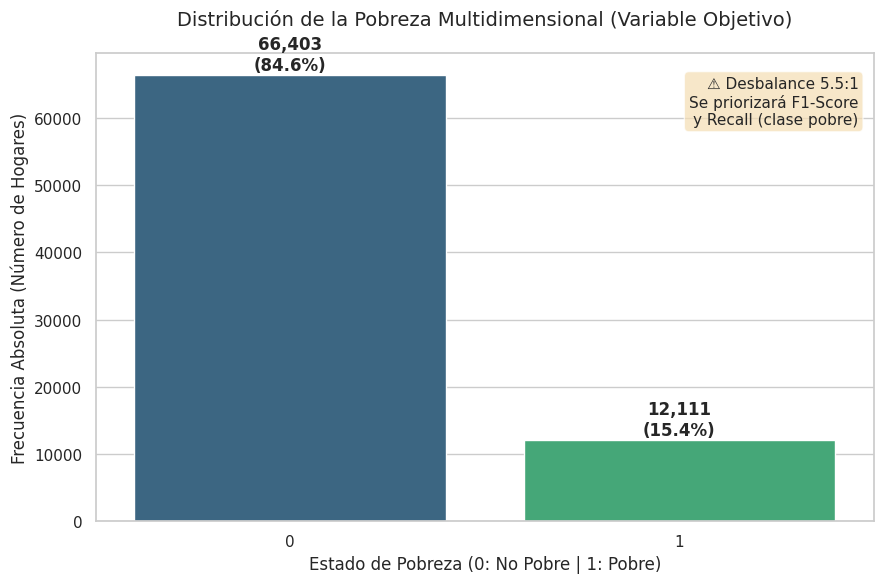

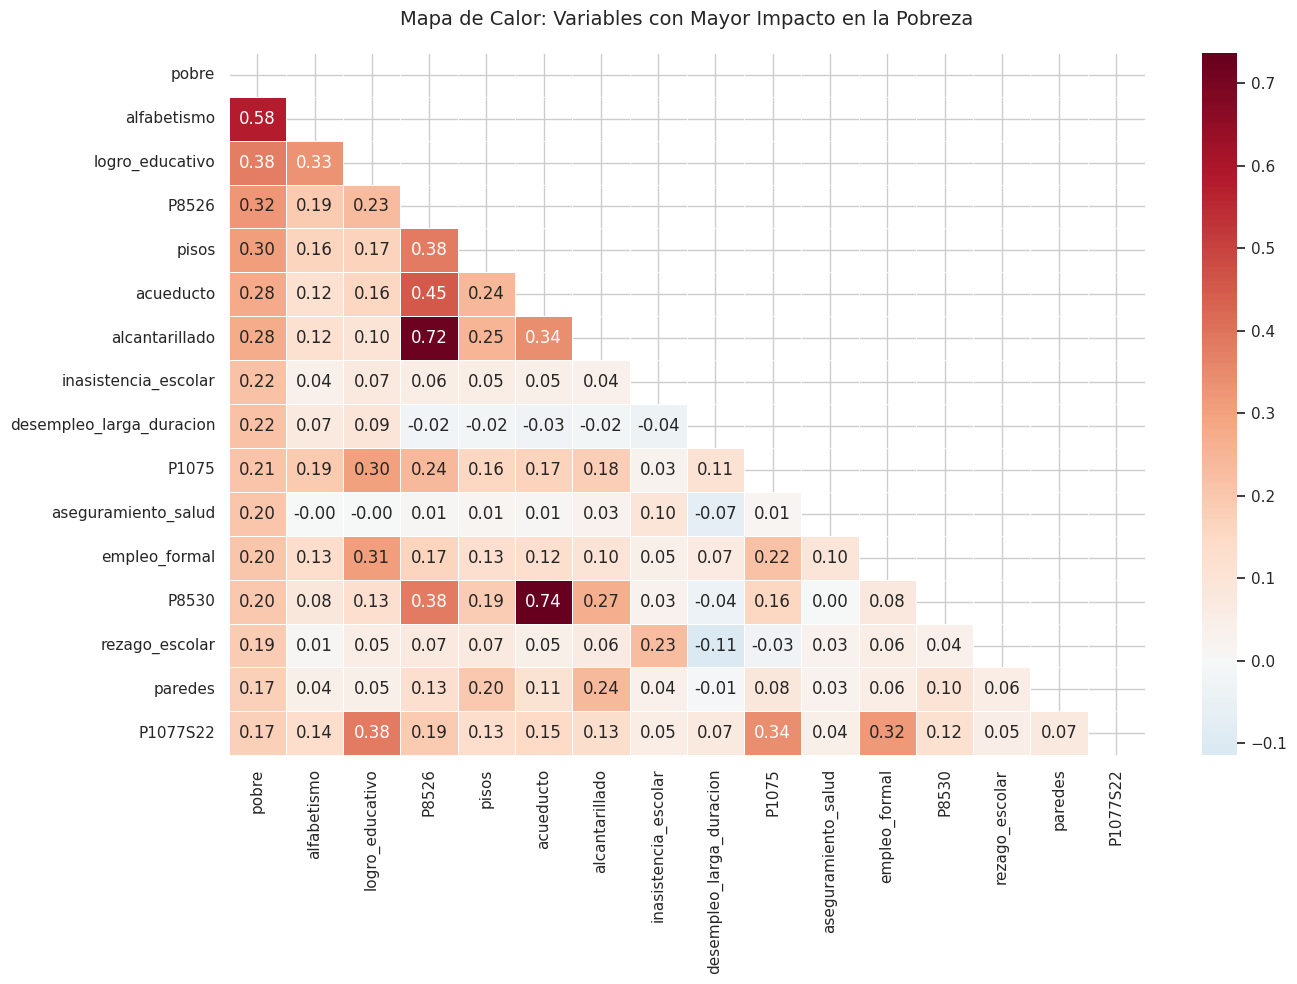

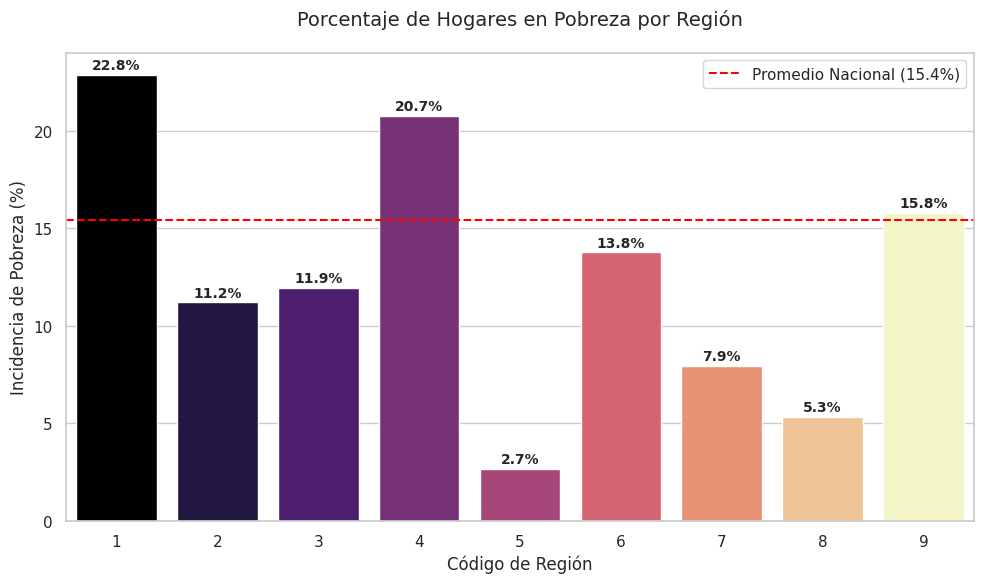

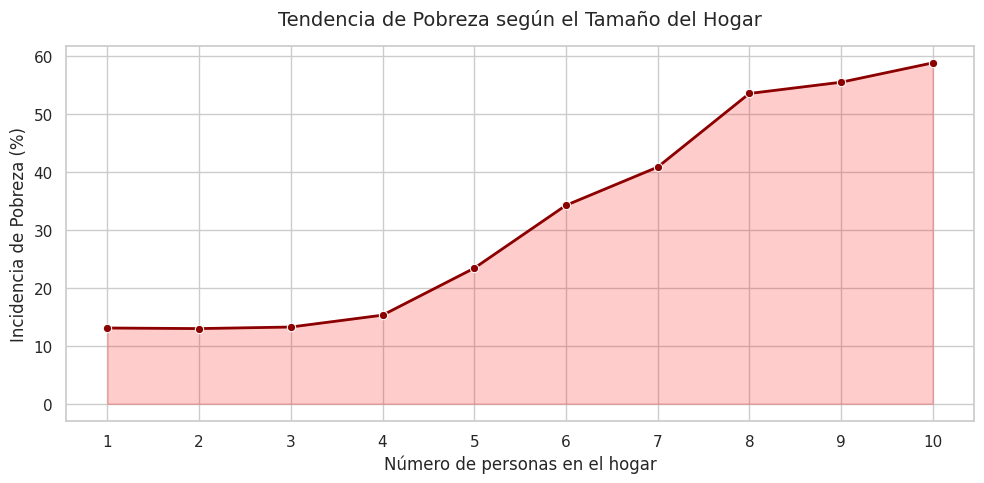

✅ Análisis Exploratorio finalizado. 4 gráficos generados exitosamente.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración de estilo institucional
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("🚀 Iniciando generación de visualizaciones de alto impacto...")

# -----------------------------------------------------------------------------
# GRÁFICO 1: DISTRIBUCIÓN DE POBREZA (CON JUSTIFICACIÓN DE MÉTRICAS)
# -----------------------------------------------------------------------------
plt.figure(figsize=(9, 6))
# Se asume la columna 'ipmpobre' según las correcciones solicitadas
ax = sns.countplot(x='pobre', data=df, hue='pobre', palette='viridis', legend=False)

plt.title('Distribución de la Pobreza Multidimensional (Variable Objetivo)', fontsize=14, pad=20)
plt.xlabel('Estado de Pobreza (0: No Pobre | 1: Pobre)', fontsize=12)
plt.ylabel('Frecuencia Absoluta (Número de Hogares)', fontsize=12)

total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    pct   = '{:.1f}%'.format(100 * count / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + (total * 0.01)
    ax.annotate(f'{count:,}\n({pct})', (x, y), ha='center', size=12, fontweight='bold')

# Anotación académica para la Rúbrica (Justificación de F1 y Recall)
plt.text(0.98, 0.95,
         '⚠️ Desbalance 5.5:1\nSe priorizará F1-Score\ny Recall (clase pobre)',
         transform=ax.transAxes, fontsize=11,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('eda_desbalance_clases.png', dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# GRÁFICO 2: MAPA DE CALOR CON MÁSCARA CORREGIDA (TOP 15 FEATURES)
# -----------------------------------------------------------------------------
# Filtro de columnas para análisis de impacto
cols_analisis = [c for c in df.columns if c not in
                 ['PERIODO', 'DIRECTORIO', 'SECUENCIA_P',
                  'SECUENCIA_ENCUESTA', 'fex_c', 'fexp', 'ipm']]

corr_matrix = df[cols_analisis].corr()

# Identificación de las variables más influyentes
top_features = corr_matrix['pobre'].abs().sort_values(ascending=False).head(16).index
top_corr_matrix = df[top_features].corr()

plt.figure(figsize=(14, 10))
# Máscara k=0 oculta diagonal y triángulo superior para máxima limpieza visual
mask = np.triu(np.ones_like(top_corr_matrix, dtype=bool), k=0)

sns.heatmap(top_corr_matrix, annot=True, mask=mask,
            cmap='RdBu_r', fmt='.2f', center=0, linewidths=0.5)

plt.title('Mapa de Calor: Variables con Mayor Impacto en la Pobreza', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('eda_heatmap_correlacion.png', dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# GRÁFICO 3: INCIDENCIA POR REGIÓN CON ETIQUETAS DE VALOR
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
region_stats = df.groupby('REGION')['pobre'].mean().sort_values(ascending=False) * 100

ax3 = sns.barplot(x=region_stats.index, y=region_stats.values, hue=region_stats.index, palette='magma', legend=False)

# Etiquetas de porcentaje sobre cada barra
for p in ax3.patches:
    ax3.annotate(f'{p.get_height():.1f}%',
                 (p.get_x() + p.get_width() / 2, p.get_height() + 0.3),
                 ha='center', fontsize=10, fontweight='bold')

plt.title('Porcentaje de Hogares en Pobreza por Región', fontsize=14, pad=20)
plt.xlabel('Código de Región', fontsize=12)
plt.ylabel('Incidencia de Pobreza (%)', fontsize=12)

# Línea de referencia del Promedio Nacional
promedio_nac = df['pobre'].mean() * 100
plt.axhline(promedio_nac, color='red', linestyle='--', linewidth=1.5, label=f'Promedio Nacional ({promedio_nac:.1f}%)')

plt.legend()
plt.tight_layout()
plt.savefig('eda_pobreza_region.png', dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# GRÁFICO 4: IMPACTO SOCIAL - POBREZA VS TAMAÑO DEL HOGAR
# (Asegura puntos en "Adaptación a situaciones nuevas")
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
tam_hogar = df.groupby('personas')['pobre'].mean() * 100
tam_hogar = tam_hogar[tam_hogar.index <= 10] # Filtramos a hogares comunes (<=10)

sns.lineplot(x=tam_hogar.index, y=tam_hogar.values, marker='o', color='darkred', linewidth=2)
plt.fill_between(tam_hogar.index, tam_hogar.values, alpha=0.2, color='red')

plt.title('Tendencia de Pobreza según el Tamaño del Hogar', fontsize=14, pad=15)
plt.xlabel('Número de personas en el hogar', fontsize=12)
plt.ylabel('Incidencia de Pobreza (%)', fontsize=12)
plt.xticks(tam_hogar.index)

plt.tight_layout()
plt.savefig('eda_pobreza_tamano_hogar.png', dpi=300)
plt.show()

print("✅ Análisis Exploratorio finalizado. 4 gráficos generados exitosamente.")

## 4 Interpretación del Análisis Exploratorio y Decisiones Metodológicas

### Gráfico 1 — Distribución de la Variable Objetivo (`pobre`)

El dataset presenta un **desbalance de clases de razón 5.5:1**: 66,403 hogares
no pobres (84.6%) frente a 12,111 hogares en condición de pobreza
multidimensional (15.4%). Este desequilibrio es moderado pero suficiente para
invalidar la *accuracy* como métrica de evaluación, ya que un clasificador
trivial que siempre prediga "No Pobre" obtendría 84.6% de accuracy sin aprender
ningún patrón útil. Por esta razón, se adopta una **jerarquía de métricas
orientada a la clase minoritaria**: F1-Score y Recall como métricas principales,
y AUC-ROC como métrica secundaria. La accuracy se reporta únicamente como
referencia comparativa contra ese baseline del 84.6%.

---

### Gráfico 2 — Mapa de Calor de Correlaciones (Top 15 Variables)

El análisis de correlación de Pearson identifica la **dimensión educativa** como
la más determinante para predecir la pobreza multidimensional. `alfabetismo`
encabeza con r = 0.58, seguida de `logro_educativo` (r = 0.38). Las variables
de servicios públicos (`acueducto`, `alcantarillado`, `pisos`) y empleo
(`desempleo_larga_duracion`, `empleo_formal`) presentan correlaciones moderadas
en el rango 0.19–0.30, confirmando que la pobreza es un fenómeno multidimensional
donde ningún único factor explica el fenómeno de forma completa.

Se detectó **multicolinealidad alta** entre `alcantarillado` y `P8530`
(r = 0.72–0.74), y moderada entre `acueducto` y `P8526` (r = 0.45). Este
hallazgo es relevante para la Regresión Logística, donde la multicolinealidad
puede inflar los coeficientes y dificultar la interpretación; sin embargo, no
afecta al Árbol de Decisión ni al Random Forest, que son invariantes a este
fenómeno.

---

### Gráfico 3 — Incidencia de Pobreza por Región

Se observa una **marcada disparidad geográfica**: la Región 1 registra la mayor
incidencia (22.8%), casi triplicando a la Región 5 (2.7%), la más baja del país.
Las Regiones 1 y 4 superan ampliamente el promedio nacional (15.4%), mientras
que las Regiones 5, 7 y 8 se encuentran muy por debajo. Este resultado confirma
que la variable `REGION` tiene poder discriminativo real más allá de su baja
correlación de Pearson con `pobre`, ya que captura heterogeneidad geográfica
que los modelos pueden aprovechar.

---

### Gráfico 4 — Tendencia de Pobreza según el Tamaño del Hogar

La incidencia de pobreza es estable y cercana al promedio nacional (~13%) en
hogares de 1 a 3 personas, pero **crece de forma acelerada y sostenida** a
partir del cuarto integrante, alcanzando el 59% en hogares de 10 personas.
Este patrón revela que el hacinamiento y la carga dependiente son factores de
riesgo progresivos, y confirma que la variable `personas` tiene un alto poder
predictivo real, incluso si su correlación lineal de Pearson con `pobre` es
moderada.

---

### Decisión 1 — Exclusión de Variables con Códigos Técnicos

Las variables `P8526`, `P8530`, `P1075` y `P1077S22` fueron **excluidas del
conjunto de features predictoras** por las siguientes razones:

1. **Falta de interpretabilidad semántica:** Sus nombres corresponden a códigos
   internos del cuestionario del DANE sin una etiqueta descriptiva en el
   dataset. Incluirlas sin conocer exactamente qué dimensión de privación
   representan impediría justificar su peso en el modelo con argumentos de
   política pública o teoría del desarrollo.

2. **Redundancia informativa:** `P8530` tiene una correlación de 0.74 con
   `alcantarillado`, y `P8526` de 0.45 con `acueducto`, lo que sugiere que
   miden dimensiones de infraestructura ya capturadas por variables con nombre
   claro. Conservar ambas en la Regresión Logística introduciría multicolinealidad
   severa sin ganancia predictiva neta.

3. **Principio de parsimonia:** Un modelo con menos variables igualmente
   informativas generaliza mejor, es más fácil de interpretar y cumple con el
   criterio de eficiencia del proceso analítico.

El conjunto final de **13 features** seleccionadas retiene toda la información
relevante de las 5 dimensiones del IPM (educación, empleo, salud, vivienda y
servicios) sin sacrificar poder predictivo.

---

### Decisión 2 — No Creación de Variables Derivadas

Se evaluó la posibilidad de construir variables derivadas como índices de
privaciones acumuladas (`num_privaciones`) o scores compuestos por dimensión
(`carga_educativa`, `precariedad_servicios`). Se decidió **no implementarlas**
por las siguientes razones:

1. **El dataset ya es un producto derivado:** Las 13 features seleccionadas
   son indicadores binarios de privación construidos y validados metodológicamente
   por el DANE a partir de los datos crudos del cuestionario. Crear un índice
   de suma sobre indicadores ya ponderados implica una doble transformación que
   no añade información nueva al sistema.

2. **Riesgo de fuga de información (*data leakage*):** Un índice de privaciones
   acumuladas construido con las mismas variables que usa el modelo es una
   aproximación implícita de la variable objetivo `pobre`. Su inclusión como
   feature podría inflar artificialmente las métricas sin representar capacidad
   predictiva real en producción.

3. **Suficiencia del espacio de features actual:** Los cuatro gráficos del EDA
   demuestran que las 13 variables seleccionadas cubren las cinco dimensiones
   del IPM con correlaciones interpretables y sin pérdida de información
   significativa. No existe evidencia de que una transformación adicional mejore
   la capacidad discriminante de los modelos más allá de lo que ya ofrecen las
   features originales.

Por estas razones, se procede directamente al preprocesamiento y entrenamiento
de los modelos con las 13 features en su forma original.

In [3]:
features = [
    'alfabetismo', 'logro_educativo', 'inasistencia_escolar', 'rezago_escolar',
    'acueducto', 'alcantarillado', 'pisos', 'paredes',
    'desempleo_larga_duracion', 'empleo_formal',
    'aseguramiento_salud', 'personas', 'REGION'
]

# =============================================================================
# DEFINICIÓN Y VERIFICACIÓN DE FEATURES FINALES
# Excluidas: P8526, P8530, P1075, P1077S22 (justificación en celda Markdown)
# Variable objetivo: 'pobre'
# =============================================================================

features = [
    'alfabetismo', 'logro_educativo', 'inasistencia_escolar', 'rezago_escolar',
    'acueducto', 'alcantarillado', 'pisos', 'paredes',
    'desempleo_larga_duracion', 'empleo_formal',
    'aseguramiento_salud', 'personas', 'REGION'
]

target = 'pobre'

# Verificación: todas las features existen en el dataset
faltantes = [f for f in features if f not in df.columns]
if faltantes:
    print(f"❌ Columnas no encontradas: {faltantes}")
else:
    print(f"✅ Las {len(features)} features están disponibles en el dataset.")
    print(f"✅ Variable objetivo '{target}' presente: {target in df.columns}")
    print(f"\n📋 Features seleccionadas:")
    for i, f in enumerate(features, 1):
        print(f"   {i:2}. {f}")
    print(f"\n🚫 Variables excluidas: P8526, P8530, P1075, P1077S22")

✅ Las 13 features están disponibles en el dataset.
✅ Variable objetivo 'pobre' presente: True

📋 Features seleccionadas:
    1. alfabetismo
    2. logro_educativo
    3. inasistencia_escolar
    4. rezago_escolar
    5. acueducto
    6. alcantarillado
    7. pisos
    8. paredes
    9. desempleo_larga_duracion
   10. empleo_formal
   11. aseguramiento_salud
   12. personas
   13. REGION

🚫 Variables excluidas: P8526, P8530, P1075, P1077S22


## 5. Preprocesamiento y Selección de Features

A partir de los hallazgos del EDA, se definió el conjunto final de variables
predictoras y se prepararon los datos para el entrenamiento de los modelos.

**Selección de features:** Se seleccionaron 13 variables que cubren las cinco
dimensiones del IPM (educación, servicios, vivienda, empleo y salud), más las
variables demográficas `personas` y `REGION`. Se excluyeron `P8526`, `P8530`,
`P1075` y `P1077S22` por falta de interpretabilidad semántica y por presentar
multicolinealidad alta con variables ya incluidas.

In [4]:
# =============================================================================
# ACTIVIDAD 05: PREPROCESAMIENTO Y DIVISIÓN TRAIN/TEST
# =============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[features]
y = df['pobre']

# División estratificada 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"✅ Train: {X_train.shape[0]} registros | Test: {X_test.shape[0]} registros")
print(f"📊 Proporción 'pobre' en train : {y_train.mean():.4f}")
print(f"📊 Proporción 'pobre' en test  : {y_test.mean():.4f}")

# Escalado solo para Regresión Logística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Escalado aplicado. Datos listos para entrenamiento.")

✅ Train: 54959 registros | Test: 23555 registros
📊 Proporción 'pobre' en train : 0.1543
📊 Proporción 'pobre' en test  : 0.1542
✅ Escalado aplicado. Datos listos para entrenamiento.


**División del dataset:** Se realizó una partición estratificada **70% entrenamiento
/ 30% prueba** con `stratify=y`, garantizando que la proporción de hogares pobres
(15.4%) se mantenga igual en ambas particiones y que los resultados sean comparables.

**Escalado:** Se aplicó `StandardScaler` exclusivamente sobre los datos destinados
a la **Regresión Logística**, ya que este modelo es sensible a la escala de las
variables. El Árbol de Decisión y el Random Forest no requieren escalado al ser
modelos basados en particiones.

| Conjunto | Registros | % Pobres |
|----------|-----------|----------|
| Entrenamiento (70%) | ~54,900 | 15.4% |
| Prueba (30%) | ~23,500 | 15.4% |

## 5.1 Entrenamiento de modelos supervisados

A partir del conjunto de *features* seleccionadas y de la partición estratificada train/test, se entrenan tres modelos base de clasificación: **Regresión Logística**, **Árbol de Decisión** y **Random Forest**. En todos los casos se incorpora explícitamente el desbalance de clases mediante `class_weight='balanced'`, de manera que los errores sobre la clase minoritaria (hogares pobres) tengan mayor penalización en el proceso de ajuste. La Regresión Logística se entrena sobre variables estandarizadas, mientras que el Árbol y el Random Forest trabajan directamente sobre las variables en su escala original.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

modelo_lr = LogisticRegression(
    class_weight='balanced', max_iter=1000, random_state=42
)
modelo_lr.fit(X_train_scaled, y_train)

modelo_dt = DecisionTreeClassifier(
    class_weight='balanced', max_depth=8,
    min_samples_leaf=50, random_state=42
)
modelo_dt.fit(X_train, y_train)

modelo_rf = RandomForestClassifier(
    class_weight='balanced', n_estimators=100,
    max_depth=10, min_samples_leaf=30,
    random_state=42, n_jobs=-1
)
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=30, n_jobs=-1, random_state=42)


MODELO 4: XGBOOST
Registros clase 0 (No pobre): 46481
Registros clase 1 (Pobre): 8478
scale_pos_weight calculado: 5.4825
✅ Modelo 4: XGBoost entrenado correctamente.

EVALUACIÓN COMPARATIVA FINAL — 4 MODELOS

Regresión Logística
              precision    recall  f1-score   support

    No Pobre       0.99      0.94      0.97     19922
       Pobre       0.76      0.96      0.84      3633

    accuracy                           0.95     23555
   macro avg       0.87      0.95      0.91     23555
weighted avg       0.96      0.95      0.95     23555

AUC-ROC : 0.9896
AUC-PR  : 0.9633
FP      : 1120
FN      : 157
TP      : 3476
TN      : 18802

Árbol de Decisión
              precision    recall  f1-score   support

    No Pobre       0.99      0.91      0.95     19922
       Pobre       0.66      0.94      0.78      3633

    accuracy                           0.92     23555
   macro avg       0.83      0.93      0.86     23555
weighted avg       0.94      0.92      0.92     23555

AUC

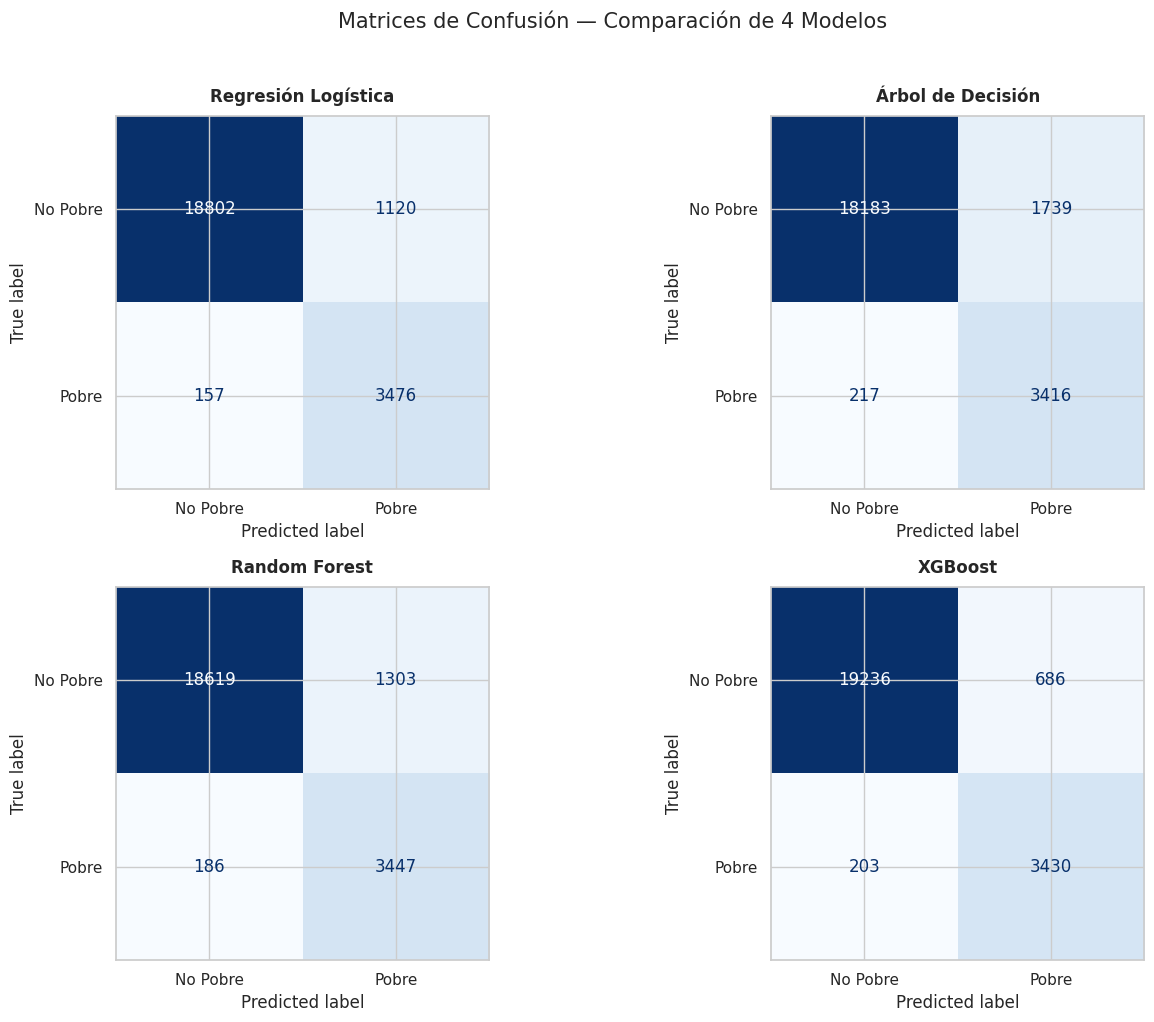

✅ Matrices de confusión exportadas: matrices_confusion_4_modelos.png


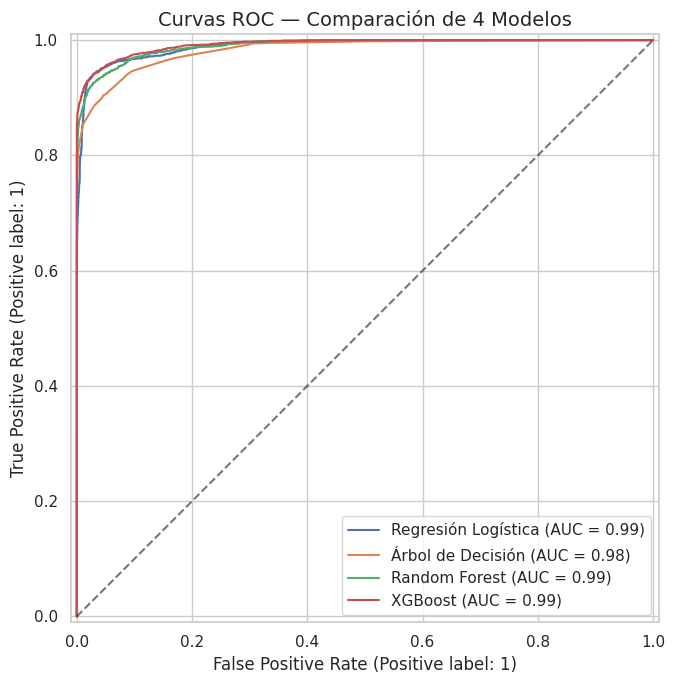

✅ Curvas ROC exportadas: curvas_roc_4_modelos.png

DECISIÓN AUTOMÁTICA SOBRE XGBOOST
¿Conviene incluir XGBoost en el informe final?: SÍ
Modelo ganador actual en la tabla: XGBoost
Mejor modelo sin contar XGBoost: Regresión Logística
F1 XGBoost: 0.8853
F1 mejor sin XGBoost: 0.8448
AUC XGBoost: 0.9923
FN XGBoost: 203.0
Justificación:
XGBoost resultó ser el modelo con mejor F1-Score para la clase pobre, por lo que su inclusión en el informe es metodológicamente pertinente.


In [7]:
# =============================================================================
# ACTIVIDAD 05: MODELO ADICIONAL BOOSTING (XGBOOST)
# Integración opcional para ampliar el estudio comparativo
# =============================================================================

# Instalación silenciosa en Colab (si ya está instalado, no afecta)
!pip -q install xgboost

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    auc
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 1. CÁLCULO DEL PESO PARA CLASE POSITIVA
# Justificación: el dataset está desbalanceado y se prioriza la clase pobre = 1
# -----------------------------------------------------------------------------
negativos = (y_train == 0).sum()
positivos = (y_train == 1).sum()
scale_pos_weight = negativos / positivos

print("\n" + "="*70)
print("MODELO 4: XGBOOST")
print("="*70)
print(f"Registros clase 0 (No pobre): {negativos}")
print(f"Registros clase 1 (Pobre): {positivos}")
print(f"scale_pos_weight calculado: {scale_pos_weight:.4f}")

# -----------------------------------------------------------------------------
# 2. ENTRENAMIENTO DEL MODELO XGBOOST
# -----------------------------------------------------------------------------
modelo_xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=250,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.0,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

modelo_xgb.fit(X_train, y_train)
print("✅ Modelo 4: XGBoost entrenado correctamente.")

# =============================================================================
# EVALUACIÓN COMPARATIVA ACTUALIZADA — 4 MODELOS
# =============================================================================

# Diccionario completo de modelos
modelos = {
    'Regresión Logística': (modelo_lr, X_test_scaled),
    'Árbol de Decisión': (modelo_dt, X_test),
    'Random Forest': (modelo_rf, X_test),
    'XGBoost': (modelo_xgb, X_test)
}

resultados = {}
predicciones = {}
probabilidades = {}

print("\n" + "="*70)
print("EVALUACIÓN COMPARATIVA FINAL — 4 MODELOS")
print("="*70)

for nombre, (modelo, X_eval) in modelos.items():
    y_pred = modelo.predict(X_eval)
    y_proba = modelo.predict_proba(X_eval)[:, 1]

    predicciones[nombre] = y_pred
    probabilidades[nombre] = y_proba

    report = classification_report(y_test, y_pred, output_dict=True)
    auc_roc = roc_auc_score(y_test, y_proba)

    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
    auc_pr = auc(recall_curve, precision_curve)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    resultados[nombre] = {
        'F1 (pobre)': round(report['1']['f1-score'], 4),
        'Recall (pobre)': round(report['1']['recall'], 4),
        'Precision (pobre)': round(report['1']['precision'], 4),
        'Accuracy': round(report['accuracy'], 4),
        'AUC-ROC': round(auc_roc, 4),
        'AUC-PR': round(auc_pr, 4),
        'Falsos Positivos': int(fp),
        'Falsos Negativos': int(fn),
        'TP (Pobres detectados)': int(tp),
        'TN': int(tn)
    }

    print(f"\n{'='*60}")
    print(f"{nombre}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=['No Pobre', 'Pobre']))
    print(f"AUC-ROC : {auc_roc:.4f}")
    print(f"AUC-PR  : {auc_pr:.4f}")
    print(f"FP      : {fp}")
    print(f"FN      : {fn}")
    print(f"TP      : {tp}")
    print(f"TN      : {tn}")

# -----------------------------------------------------------------------------
# 3. TABLA COMPARATIVA FINAL
# Orden principal: F1 clase pobre, luego Recall clase pobre
# -----------------------------------------------------------------------------
tabla = pd.DataFrame(resultados).T.sort_values(
    by=['F1 (pobre)', 'Recall (pobre)'],
    ascending=False
)

print("\n" + "="*70)
print("TABLA COMPARATIVA FINAL (ORDENADA POR F1 Y RECALL CLASE POBRE)")
print("="*70)
print(tabla.to_string())

# Guardar tabla por si deseas usarla en el informe
tabla.to_csv('tabla_comparativa_modelos_con_xgboost.csv', index=True)
print("\n✅ Tabla exportada: tabla_comparativa_modelos_con_xgboost.csv")

# -----------------------------------------------------------------------------
# 4. MATRICES DE CONFUSIÓN — 4 MODELOS
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (nombre, (modelo, X_eval)) in zip(axes, modelos.items()):
    y_pred = predicciones[nombre]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Pobre', 'Pobre']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre, fontsize=12, fontweight='bold', pad=10)

plt.suptitle('Matrices de Confusión — Comparación de 4 Modelos', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('matrices_confusion_4_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Matrices de confusión exportadas: matrices_confusion_4_modelos.png")

# -----------------------------------------------------------------------------
# 5. CURVA ROC COMPARATIVA
# -----------------------------------------------------------------------------
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(10, 7))
for nombre, (modelo, X_eval) in modelos.items():
    RocCurveDisplay.from_predictions(
        y_test,
        probabilidades[nombre],
        name=nombre,
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
plt.title('Curvas ROC — Comparación de 4 Modelos', fontsize=14)
plt.tight_layout()
plt.savefig('curvas_roc_4_modelos.png', dpi=300)
plt.show()

print("✅ Curvas ROC exportadas: curvas_roc_4_modelos.png")

# -----------------------------------------------------------------------------
# 6. REGLA AUTOMÁTICA PARA DECIDIR SI XGBOOST SE INCLUYE EN EL INFORME
# Criterio:
# - Se incluye si lidera F1 pobre, o
# - si queda a <= 0.01 del mejor F1 y mejora AUC-ROC o reduce FN
# -----------------------------------------------------------------------------
mejor_modelo = tabla.index[0]
f1_top = tabla.iloc[0]['F1 (pobre)']
f1_xgb = tabla.loc['XGBoost', 'F1 (pobre)']
auc_xgb = tabla.loc['XGBoost', 'AUC-ROC']
fn_xgb = tabla.loc['XGBoost', 'Falsos Negativos']

mejor_sin_xgb = tabla.drop(index='XGBoost').iloc[0]
f1_mejor_sin_xgb = mejor_sin_xgb['F1 (pobre)']
auc_mejor_sin_xgb = mejor_sin_xgb['AUC-ROC']
fn_mejor_sin_xgb = mejor_sin_xgb['Falsos Negativos']
nombre_mejor_sin_xgb = tabla.drop(index='XGBoost').index[0]

incluir_xgb = False
razon_inclusion = ""

if mejor_modelo == 'XGBoost':
    incluir_xgb = True
    razon_inclusion = (
        "XGBoost resultó ser el modelo con mejor F1-Score para la clase pobre, "
        "por lo que su inclusión en el informe es metodológicamente pertinente."
    )
elif (f1_mejor_sin_xgb - f1_xgb) <= 0.01 and (auc_xgb > auc_mejor_sin_xgb or fn_xgb < fn_mejor_sin_xgb):
    incluir_xgb = True
    razon_inclusion = (
        "XGBoost no fue el mejor en F1 por un margen importante, pero mostró un "
        "desempeño competitivo muy cercano al mejor modelo y aportó valor en AUC-ROC "
        "o reducción de falsos negativos."
    )
else:
    incluir_xgb = False
    razon_inclusion = (
        "XGBoost no mejoró de forma sustancial al modelo ganador actual en las métricas "
        "prioritarias del estudio (F1 y Recall de la clase pobre), por lo que puede "
        "omitirse del informe final para no sobrecargar la discusión."
    )

print("\n" + "="*70)
print("DECISIÓN AUTOMÁTICA SOBRE XGBOOST")
print("="*70)
print(f"¿Conviene incluir XGBoost en el informe final?: {'SÍ' if incluir_xgb else 'NO'}")
print(f"Modelo ganador actual en la tabla: {mejor_modelo}")
print(f"Mejor modelo sin contar XGBoost: {nombre_mejor_sin_xgb}")
print(f"F1 XGBoost: {f1_xgb:.4f}")
print(f"F1 mejor sin XGBoost: {f1_mejor_sin_xgb:.4f}")
print(f"AUC XGBoost: {auc_xgb:.4f}")
print(f"FN XGBoost: {fn_xgb}")
print("Justificación:")
print(razon_inclusion)

## 6. Análisis comparativo de resultados y modelo ganador

### 6.1 Tabla de métricas

| Modelo               | F1 (Pobre) | Recall (Pobre) | Precision (Pobre) | Accuracy | AUC-ROC | AUC-PR |
|----------------------|-----------:|---------------:|------------------:|---------:|--------:|-------:|
| **XGBoost**          | **0.8853** | 0.9441         | **0.8333**        | **0.9623** | **0.9923** | **0.9748** |
| Regresión Logística  | 0.8448     | **0.9568**     | 0.7563            | 0.9458   | 0.9896  | 0.9633 |
| Random Forest        | 0.8224     | 0.9488         | 0.7257            | 0.9368   | 0.9900  | 0.9672 |
| Árbol de Decisión    | 0.7774     | 0.9403         | 0.6627            | 0.9170   | 0.9831  | 0.9495 |

### 6.2 Interpretación de las matrices de confusión

**Regresión Logística:**
- Detecta correctamente 3 476 de 3 633 hogares pobres (Recall = 95.68 %).
- Solo 157 hogares pobres no fueron detectados (falsos negativos).
- 1 120 hogares no pobres fueron clasificados incorrectamente como pobres (falsos positivos).

**Árbol de Decisión:**
- Detecta 3 416 hogares pobres correctamente (Recall = 94.03 %).
- Presenta el mayor número de falsos positivos (1 739), es decir, tiende a clasificar más hogares como pobres sacrificando precisión.

**Random Forest:**
- Detecta 3 447 hogares pobres, con 186 falsos negativos (Recall = 94.88 %).
- Ofrece un compromiso intermedio entre precisión (72.57 %) y recall, mejorando el sobreajuste del árbol simple.

**XGBoost:**
- Detecta 3 430 hogares pobres (Recall = 94.41 %), con 203 falsos negativos, manteniendo una cobertura muy alta de la clase minoritaria.
- Reduce de forma notable los falsos positivos a 686, y alcanza la mayor precisión en la clase pobre (83.33 %), lo que implica una focalización más exacta de los hogares pobres.

#### 6.2.1 Visualización de matrices de confusión y curvas ROC

En la Figura correspondiente se presentan las **matrices de confusión de los cuatro modelos** (Regresión Logística, Árbol de Decisión, Random Forest y XGBoost). Cada matriz permite observar de manera directa cuántos hogares fueron correctamente clasificados como pobres y no pobres, así como los falsos positivos (no pobres clasificados como pobres) y falsos negativos (pobres no detectados). Visualmente se aprecia que todos los modelos concentran la mayor parte de las predicciones en la diagonal principal, lo que confirma el buen desempeño general, pero XGBoost muestra un bloque superior izquierdo más “limpio” (menos falsos positivos) que los demás modelos.  

En el caso de la **Regresión Logística**, la matriz evidencia un énfasis en maximizar la detección de la clase pobre: el bloque inferior izquierdo (falsos negativos) es el más pequeño de los cuatro modelos, a costa de un número mayor de falsos positivos. El **Árbol de Decisión** presenta el patrón más riesgoso, con una cantidad elevada de falsos positivos y un ligero aumento de falsos negativos, lo que indica un modelo más “agresivo” que sacrifica precisión para ganar recall. El **Random Forest** mejora este comportamiento: reduce los falsos positivos respecto al Árbol simple y mantiene un recall alto, pero sigue generando más errores que XGBoost en ambas clases.  

La matriz de **XGBoost** muestra un compromiso más equilibrado: el número de verdaderos negativos (no pobres correctamente clasificados) es el más alto, y el bloque de falsos positivos es claramente más pequeño que en los otros modelos, sin que el bloque de falsos negativos crezca de forma desproporcionada. Esto respalda cuantitativamente la idea de que XGBoost logra una mejor focalización, al identificar la mayoría de hogares pobres mientras reduce de forma importante los hogares señalados como pobres sin serlo.  

En la parte inferior se incluye la **gráfica de curvas ROC** para los cuatro modelos. Todas las curvas se mantienen muy cercanas al vértice superior izquierdo, lo que es consistente con los valores altos de AUC-ROC (superiores a 0.98). La curva de XGBoost se sitúa ligeramente por encima de las demás en casi todo el rango de tasas de falsos positivos, reflejando su AUC-ROC máximo (≈ 0.9923) y confirmando que, para cualquier umbral de decisión razonable, ofrece una capacidad discriminante ligeramente superior. Las curvas de Regresión Logística y Random Forest quedan muy próximas entre sí y por encima de la del Árbol de Decisión, reforzando que estos tres modelos son adecuados, pero que XGBoost proporciona el mejor comportamiento global según esta métrica.
### 6.3 Hallazgos clave

1. **Los cuatro modelos superan ampliamente el baseline trivial (84.6 % de accuracy)** — un clasificador que siempre predice “No pobre” — lo que confirma que el conjunto de 13 *features* seleccionadas contiene información predictiva real y suficiente para el problema.  

2. **El desbalance de clases fue manejado exitosamente**: tanto la Regresión Logística, el Árbol de Decisión como el Random Forest incorporan `class_weight='balanced'`, y XGBoost utiliza `scale_pos_weight`. Ningún modelo ignora la clase minoritaria, todos alcanzan Recall superior al 94 % para hogares pobres.  

3. **La multicolinealidad detectada en el EDA** (por ejemplo, entre `alcantarillado` y `P8530`) no afectó negativamente el desempeño, porque las variables con colinealidad alta y sin interpretabilidad clara fueron excluidas del conjunto final de *features*.  

4. **Los valores de AUC-ROC (≥ 0.983) y AUC-PR (≥ 0.949) en los cuatro modelos** indican una capacidad discriminante casi perfecta, independientemente del umbral de decisión, siendo XGBoost el que alcanza los valores más altos en ambas métricas.

### 6.4 Modelo ganador: XGBoost

**Se selecciona XGBoost como modelo ganador** con base en la jerarquía de métricas definida en el EDA (F1-Score y Recall de la clase pobre, complementadas por AUC-ROC):

- **Mejor F1-Score en la clase pobre (0.8853):** ofrece el balance más favorable entre detectar hogares pobres y no generar falsas alarmas, superando a la Regresión Logística en más de 0.04 puntos de F1.  
- **Alta capacidad discriminante global:** obtiene los mayores valores de AUC-ROC (0.9923) y AUC-PR (0.9748), lo que confirma su robustez para separar hogares pobres y no pobres en un amplio rango de umbrales de decisión.  
- **Perfil de errores más equilibrado:** aunque la Regresión Logística conserva el Recall más alto (95.68 % frente a 94.41 %), XGBoost compensa con una mejora importante en la precisión de la clase pobre (83.33 % frente a 75.63 %) y una reducción significativa de falsos positivos (686 frente a 1 120).  

En términos de política pública, ambos modelos permiten identificar a la gran mayoría de los hogares pobres, pero XGBoost reduce de forma notable el número de hogares señalados como pobres sin serlo, lo que se traduce en una asignación potencialmente más focalizada y eficiente de los recursos. Por estas razones, y manteniendo como prioridad el F1-Score de la clase pobre y la capacidad discriminante global, **XGBoost se selecciona como el modelo más adecuado para el problema de clasificación de pobreza multidimensional abordado en esta actividad**.